# Photoswitching fingerprint fitting procedure
## 1 Fluorophore system

In [28]:
import os
import sys
import glob

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr
import src.routines as ro

import numpy as np
import pandas as pd

from lmfit import Model, Parameters

%load_ext autoreload
%autoreload 2

import warnings

def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Reading the data
The data is from a simulation of a single fluorophore with differing photophysical bleaching rates

In [6]:
identifiers = ['1e1', '1e2', '1e3', '1e4']
bleaching_times_all = []
fingerprints_all = []
fingerprints_discard = []

for _ in identifiers:
    fingerprints_all.append(pd.Series(np.zeros(300001), 
                                      np.round(np.linspace(0, 300, 300001), decimals=12), 
                                      dtype=np.int32))
    fingerprints_discard.append(pd.Series(np.zeros(299001), 
                                      np.round(np.linspace(1, 300, 299001), decimals=12), 
                                      dtype=np.int32))
folder_path = r"C:\Users\vie43sq\Desktop\Simulations\simulation_data\bl_rate"
for file in glob.glob(folder_path + "/*"):
    if file.endswith(".npy"):
        bleaching_times_all.append(np.load(file))
    elif file.endswith(".parquet"):
        for id in identifiers:
            if id in file:
                fingerprints_all[identifiers.index(id)] += pd.read_parquet(file).sum(axis=1)
                fingerprints_discard[identifiers.index(id)] += pd.read_parquet(file).iloc[1000:].sum(axis=1)
                break

for i, (fingerprint, fingerprint_discard) in enumerate(zip(fingerprints_all, fingerprints_discard)):
    fingerprint = fingerprint.cumsum() / fingerprint.sum()
    fingerprints_all[i] = fingerprint
    fingerprint_discard = fingerprint_discard.cumsum() / fingerprint_discard.sum()
    fingerprints_discard[i] = fingerprint_discard

### Fitting the bleaching times
The bleaching times histogram can be directly fitted with a PDF. If some assumptions hold, a fluorophore bleaches with 2 rates. One for the bias due to simulation and experiment starting in an all-ON state (S0). The other for the unbiased case when the probability of finding an ON state at a given time is constant. These rates are termed *global bleaching rate*. It is the inverse of the lifetime of a fluorophore starting from the previous bleaching event.

However, depending on the probability, the fluorophores do not actually bleach within the given time - therefore, the MLE procedure can also cover the number of runs without events. 

Still, in real experiments, the bleaching times are not extractable - also, fitting the PDF directly may result in a noisy fit. However, the fingerprints of a *single fluorophore* directly resemble the CDF of bleaching times. These plots are not as noisy and hence may result in a better fit. 

The 2-rate-approximation results in a 2-component exponential mixture distribution. 

In [31]:
# for a single fluorophore, the fingerprints can be fitted with a two-exponential mixture cdf model 
model = Model(dist.two_expon_mixture_cdf)
params = Parameters()
params.add('lambda1', value=1, min=0)
params.add('lambda2', value=0.5, min=0)
params.add('p', value=0.5, min=0, max=1)

WARNING for line:             df = fun(x) - f0
 invalid value encountered in subtract 
WARNING for line:     log_likelihood_observation = np.log(exp1 + exp2)
 divide by zero encountered in log 


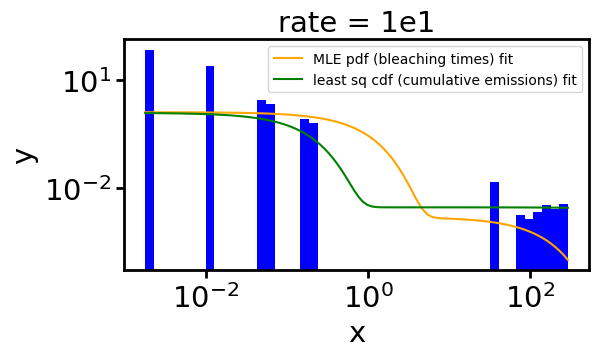

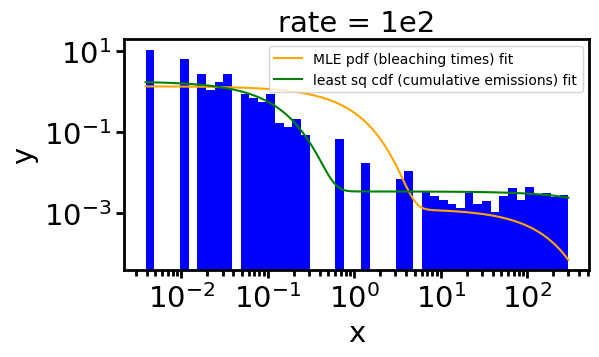

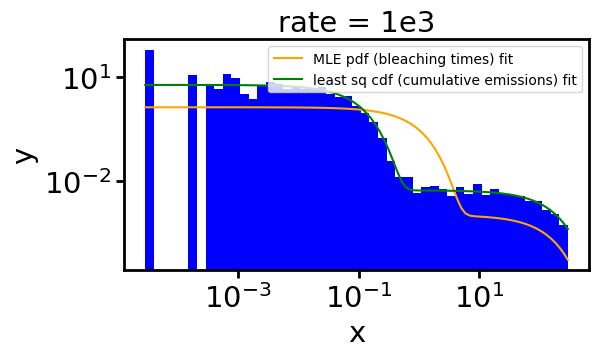

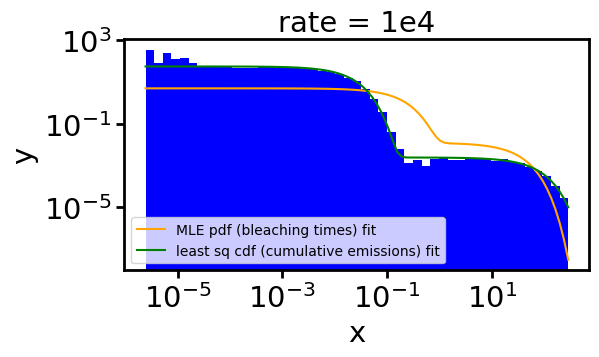

In [39]:
# In case there are multiple fluorophores, the bleaching times have to converted to
# delta bleaching times (i.e., the time between two bleaching events)
# In case there is a single fluorophore, the bleaching times are already delta bleaching
# times
parameters_cdf_fit_all = []
for i, (bleaching_times, fingerprint) in enumerate(zip(bleaching_times_all, fingerprints_all)):
    parameters_pdf_fit, delta_bleaching_times = ro.get_global_bleaching_rates(bleaching_times)
    cdf_fit = model.fit(fingerprint, params, x=np.linspace(0, 300, 300001))
    parameters_cdf_fit = [[param.value for param in cdf_fit.params.values()]]
    parameters_cdf_fit_all.append(parameters_cdf_fit)
    for delta_bleaching_times_f, param_pdf, param_cdf in zip(delta_bleaching_times, parameters_pdf_fit, parameters_cdf_fit):
        x = np.logspace(np.log10(np.min(delta_bleaching_times_f)), np.log10(np.max(delta_bleaching_times_f)), 100)
        bins_delta = np.logspace(np.log10(np.min(delta_bleaching_times_f)), np.log10(np.max(delta_bleaching_times_f)), 50)
        ax_delta = fi.universal_figure(type_='hist', bins=bins_delta, data=delta_bleaching_times_f, 
                                    density=True)
        fi.universal_figure(data=[x, dist.two_expon_mixture_pdf(x,lambda1=param_pdf[0], lambda2=param_pdf[1], p=param_pdf[2])], 
                            axes=ax_delta, color='orange', label='MLE pdf (bleaching times) fit')
        fi.universal_figure(data=[x, dist.two_expon_mixture_pdf(x, lambda1=param_cdf[0], lambda2=param_cdf[1], p=param_cdf[2],)],
                            axes=ax_delta, color='green', label='least sq cdf (cumulative emissions) fit',
                            xscale='log', yscale='log', title=f'rate = {identifiers[i]}', legend=True)

### Fitting the cumulative emissions

array([[<Axes: title={'center': 'bleaching rate'}, xlabel='time (s)', ylabel='emissions [frac]'>]],
      dtype=object)

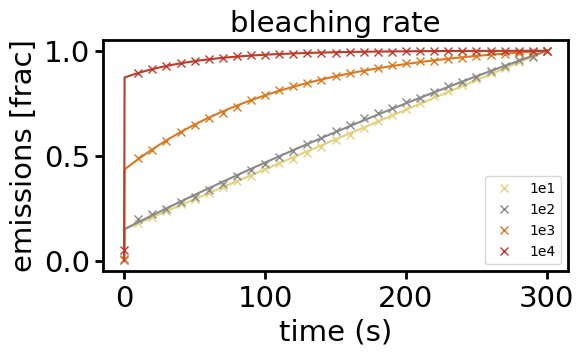

In [41]:
labels = ['1e1', '1e2', '1e3', '1e4']
colors = ['#E4D17E', '#898989', '#DB7921', '#BF3A2B']
ax = None
x = np.linspace(0, 300, 1000)
for (fingerprint, parameters, label, color) in zip(fingerprints_all, parameters_cdf_fit_all, labels, colors):
    lambda1, lambda2, pi = parameters[0]
    if ax is None:
        ax = fi.universal_figure(data=[fingerprint.index[::10000], fingerprint[::10000]], label=label, color=color, marker='x', linestyle='')
    else:
        fi.universal_figure(data=[fingerprint.index[::10000], fingerprint[::10000]], axes=ax[0], label=label, color=color, marker='x', linestyle='')
    fi.universal_figure(data=[x, dist.two_expon_mixture_cdf(x, lambda1, lambda2, pi)], axes=ax[0], color=color)
fi.universal_figure(title='bleaching rate', ylabel='emissions [frac]', xlabel='time (s)', legend=True, axes=ax[0])

array([[<Axes: title={'center': 'bleaching rate'}, xlabel='time (s)', ylabel='emissions [frac]'>]],
      dtype=object)

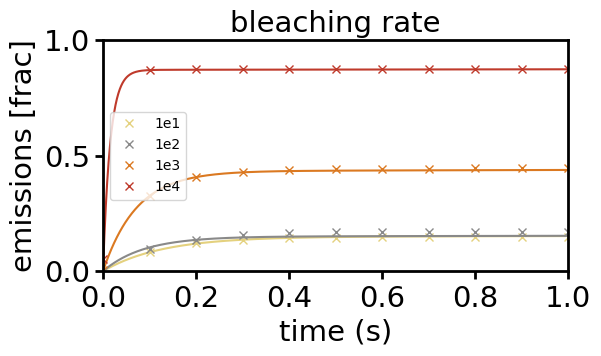

In [42]:
labels = ['1e1', '1e2', '1e3', '1e4']
colors = ['#E4D17E', '#898989', '#DB7921', '#BF3A2B']
ax = None
x = np.linspace(0, 300, 300001)
for (fingerprint, parameters, label, color) in zip(fingerprints_all, parameters_cdf_fit_all, labels, colors):
    lambda1, lambda2, pi = parameters[0]
    if ax is None:
        ax = fi.universal_figure(data=[fingerprint.index[::100], fingerprint[::100]], label=label, color=color, marker='x', linestyle='')
    else:
        fi.universal_figure(data=[fingerprint.index[::100], fingerprint[::100]], axes=ax[0], label=label, color=color, marker='x', linestyle='')
    fi.universal_figure(data=[x, dist.two_expon_mixture_cdf(x, lambda1, lambda2, pi)], axes=ax[0], color=color)
fi.universal_figure(title='bleaching rate', ylabel='emissions [frac]', xlabel='time (s)', legend=True, axes=ax[0], xlim=[0, 1], ylim=[0, 1])

array([[<Axes: title={'center': 'bleaching rate'}, xlabel='time (s)', ylabel='emissions [frac]'>]],
      dtype=object)

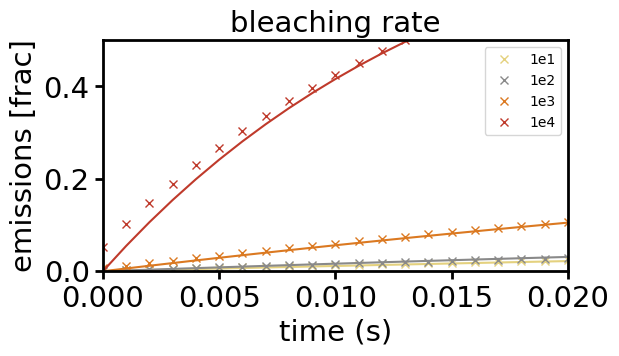

In [43]:
labels = ['1e1', '1e2', '1e3', '1e4']
colors = ['#E4D17E', '#898989', '#DB7921', '#BF3A2B']
ax = None
x = np.linspace(0, 300, 300001)
for (fingerprint, parameters, label, color) in zip(fingerprints_all, parameters_cdf_fit_all, labels, colors):
    lambda1, lambda2, pi = parameters[0]
    if ax is None:
        ax = fi.universal_figure(data=[fingerprint.index, fingerprint], label=label, color=color, marker='x', linestyle='')
    else:
        fi.universal_figure(data=[fingerprint.index, fingerprint], axes=ax[0], label=label, color=color, marker='x', linestyle='')
    fi.universal_figure(data=[x, dist.two_expon_mixture_cdf(x, lambda1, lambda2, pi)], axes=ax[0], color=color)
fi.universal_figure(title='bleaching rate', ylabel='emissions [frac]', xlabel='time (s)', legend=True, axes=ax[0], xlim=[0, 0.02], ylim=[0, 0.5])

### Approximation limits
The 2-exponential components approximation assumes two things: that there are only 2 components, and that they are exponentially distributed. This, however, can be a bad approximation of reality depending on the conditions. 
For example, below is the detailed plot of the beggining of the fingerprint. One can see the discrepancies between the fit and the data. \
The **bias** of a *single fluorophore* system concerns the first ON state. Hence, the times of bleaching within this first ON state should be exponentially distributed - however, in some cases, the fluorophore might bleach in the very first acquired triplet state, whereas in other cases, some cis lifetimes and other things are happening before that. Hence, the exponential distribution approximation of the bias does not work properly here. 
The exponential approximation of waiting times until photobleaching within the first ON state hence need photobleaching to have a *low probability*. Then, the times until photobleaching become heavy-tailed and approach an exponential distribution. Here is why: Each time the system can 'decide' to photobleach or not, it increases the number of 'trials' - Bernoulli trials. Hence, the number of trials K until success is geometrically distributed with sucess probability p. The average time between these trials is T_mean, then the total time until sucess is K * T_mean. If p becomes small, the geometric distribution resembles a Poisson process in discrete time and can be approximated by an exponential distribution. Additionally, the (unknown and complicated) distribution of T loses influence as K increases. In more detail, the times until Markov chain absorption T_abs will be K sums of T. Due to CLT and Law of large numbers (LLN) the distribution of T_abs of a fixed K will be normal. However, K is not fixed but geometrically distributed. This randomness lets T_abs converge to the exponential distribution, with lambda = p/T_mean. \
The **non-biased** part concerns the time after the first ON state (note that it is not strictly cut at the end of the ON state, because this would create a bias that there is an OFF state in the beginning). This part is approximately exponentially distributed, because the lifetimes of the OFF state, which are the main component of time progression, are exponentially distributed. 

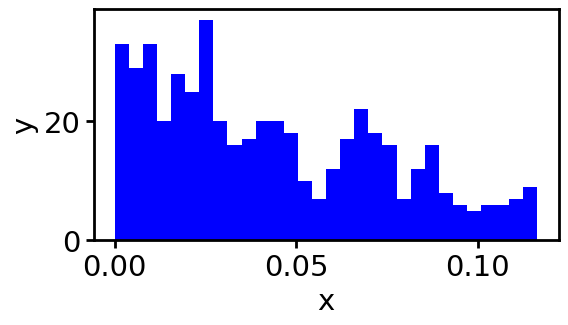

In [50]:
data = np.sort(bleaching_times_all[2][:, 0])[:500]
ax = fi.universal_figure(type_='hist', bins=30, data=data, density=False)

array([[<Axes: xlabel='x', ylabel='y'>]], dtype=object)

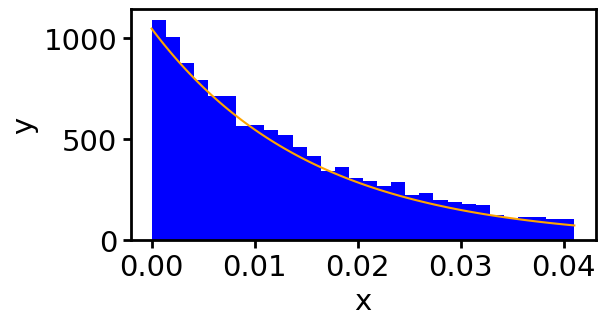

In [84]:
data = np.sort(bleaching_times_all[3][:, 0])[:12000]
ax = fi.universal_figure(type_='hist', bins=30, data=data, density=False)
x = np.linspace(0, np.max(data), 100)
fi.universal_figure(data=[x, 15*dist.two_expon_mixture_pdf(x, lambda1=parameters_cdf_fit_all[3][0][0], lambda2=parameters_cdf_fit_all[3][0][1], p=parameters_cdf_fit_all[3][0][2])], axes=ax, color='orange', label='MLE pdf (bleaching times) fit')

## Performance comparison of k-fluorophore fits

In [6]:
from sklearn.metrics import r2_score

In [14]:
parameters_all_fit_cdf

[[0.9948736547706261, 9.924465084321099e-05, 7.947636925423474],
 [0.050246638769592455, 11.53887590727966, 0.0011866686782180391],
 [0.4142193127354576, 13.894531267327267, 0.008636011080659367],
 [0.8714993105074662, 64.84228385244336, 0.01893185582135337]]

In [15]:
r2_score_1F = r2_score(fingerprints_all[3], dist.two_expon_mixture_cdf(np.linspace(0, 300, 300001), 64.84228385244336, 0.01893185582135337, 0.8714993105074662))

In [16]:
r2_score_1F

0.9993107280835585

In [18]:
r2_score_4F = r2_score(fingerprints_all[3], dist.fit_4_fluorophore(np.linspace(0, 300, 300001), 2.391e2, 9.988e1, 9.136e1, 8.501e1,
                        8.854e0, 8.692e0, 1.987e-2, 4.705e-5,
                        9.999e-1, 9.987e-1, 5.805e-1, 5.284e-1))

In [19]:
r2_score_4F

0.9995015651169705

array([[<Axes: title={'center': 'bleaching rate'}, xlabel='time (s)', ylabel='% emission'>]],
      dtype=object)

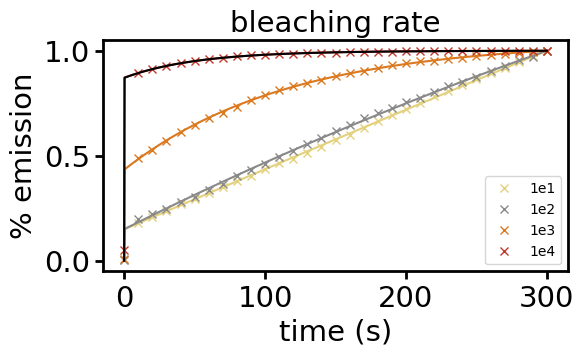

In [14]:
labels = ['1e1', '1e2', '1e3', '1e4']
colors = ['#E4D17E', '#898989', '#DB7921', '#BF3A2B']
ax = None
x = np.linspace(0, 300, 1000)
for (fingerprint, parameters, label, color) in zip(fingerprints_all, parameters_all_fit_cdf, labels, colors):
    pi, lambda1, lambda2 = parameters
    if ax is None:
        ax = fi.universal_figure(data=[fingerprint.index[::10000], fingerprint[::10000]], label=label, color=color, marker='x', linestyle='')
    else:
        fi.universal_figure(data=[fingerprint.index[::10000], fingerprint[::10000]], axes=ax[0], label=label, color=color, marker='x', linestyle='')
    fi.universal_figure(data=[x, dist.two_expon_mixture_cdf(x, lambda1, lambda2, pi)], axes=ax[0], color=color)
fi.universal_figure(data=[x, dist.fit_4_fluorophore(x, 2.391e2, 9.988e1, 9.136e1, 8.501e1,
                        8.854e0, 8.692e0, 1.987e-2, 4.705e-5,
                        9.999e-1, 9.987e-1, 5.805e-1, 5.284e-1)], color='black', axes=ax[0])
fi.universal_figure(title='bleaching rate', ylabel='% emission', xlabel='time (s)', legend=True, axes=ax[0])


array([[<Axes: title={'center': 'bleaching rate'}, xlabel='time (s)', ylabel='% emission'>]],
      dtype=object)

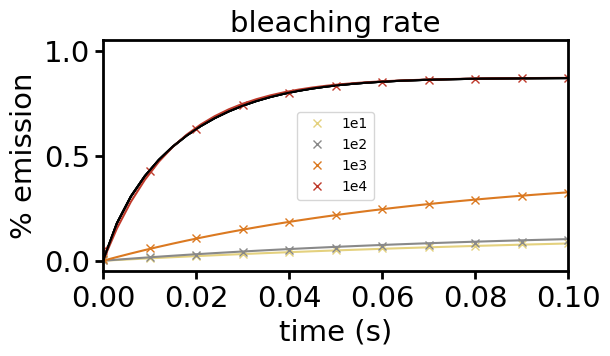

In [44]:
labels = ['1e1', '1e2', '1e3', '1e4']
colors = ['#E4D17E', '#898989', '#DB7921', '#BF3A2B']
ax = None
x = np.linspace(0, 300, 100000)
for (fingerprint, parameters, label, color) in zip(fingerprints_all, parameters_cdf_fit_all, labels, colors):
    lambda1, lambda2, pi = parameters[0]
    if ax is None:
        ax = fi.universal_figure(data=[fingerprint.index[::10], fingerprint[::10]], label=label, color=color, marker='x', linestyle='')
    else:
        fi.universal_figure(data=[fingerprint.index[::10], fingerprint[::10]], axes=ax[0], label=label, color=color, marker='x', linestyle='')
    fi.universal_figure(data=[x, dist.two_expon_mixture_cdf(x, lambda1, lambda2, pi)], axes=ax[0], color=color)
    fi.universal_figure(data=[x, dist.fit_4_fluorophore(x, 2.391e2, 9.988e1, 9.136e1, 8.501e1,
                        8.854e0, 8.692e0, 1.987e-2, 4.705e-5,
                        9.999e-1, 9.987e-1, 5.805e-1, 5.284e-1)], color='black', axes=ax[0])
fi.universal_figure(title='bleaching rate', ylabel='% emission', xlabel='time (s)', legend=True, axes=ax[0], xlim=[0, 0.1])

In [85]:
fingerprints_all[3][0]

0.05324914554911881

array([[<Axes: title={'center': 'bleaching rate'}, xlabel='time (s)', ylabel='emissions [frac]'>]],
      dtype=object)

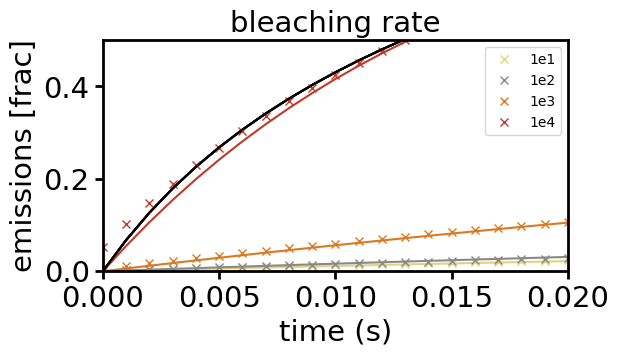

In [45]:
labels = ['1e1', '1e2', '1e3', '1e4']
colors = ['#E4D17E', '#898989', '#DB7921', '#BF3A2B']
ax = None
x = np.linspace(0, 300, 300001)
for (fingerprint, parameters, label, color) in zip(fingerprints_all, parameters_cdf_fit_all, labels, colors):
    lambda1, lambda2, pi = parameters[0]
    if ax is None:
        ax = fi.universal_figure(data=[fingerprint.index, fingerprint], label=label, color=color, marker='x', linestyle='')
    else:
        fi.universal_figure(data=[fingerprint.index, fingerprint], axes=ax[0], label=label, color=color, marker='x', linestyle='')
    fi.universal_figure(data=[x, dist.two_expon_mixture_cdf(x, lambda1, lambda2, pi)], axes=ax[0], color=color)
    fi.universal_figure(data=[x, dist.fit_4_fluorophore(x, 2.391e2, 9.988e1, 9.136e1, 8.501e1,
                        8.854e0, 8.692e0, 1.987e-2, 4.705e-5,
                        9.999e-1, 9.987e-1, 5.805e-1, 5.284e-1)], color='black', axes=ax[0])
fi.universal_figure(title='bleaching rate', ylabel='emissions [frac]', xlabel='time (s)', legend=True, axes=ax[0], xlim=[0, 0.02], ylim=[0, 0.5])

### Fitting the data using the 4-fluorophore model (intentionally wrong)

##### Using global optimization differential_evolution

In [11]:
from scipy.optimize import differential_evolution, LinearConstraint
from sklearn.metrics import r2_score


x_data = np.linspace(0, 300, 300001)
y_data = fingerprints_all[3].values

def objective_function(params):
    y_pred = dist.fit_4_fluorophore(x_data, *params)
    error = np.sum((y_data - y_pred) ** 2)

    return error

bounds = [(1, 500), (1, 500), (0.1, 100), (0.1, 100), (1e-2, 10), (1e-2, 10), (1e-4, 1), 
(1e-8, 1e-2), (0, 1), (0, 1), (0, 1), (0, 1)]

##### set up constraints

In [12]:
epsilon = 1e-3
linear_constraint1 = LinearConstraint(
    A=[[1, -1, 0, 0,  # lam1_1 > lam2_1 
        0, 0, 0, 0, 
        0, 0, 0, 0,],
        [0, 1, -1, 0,  # lam2_1 > lam3_1
        0, 0, 0, 0, 
        0, 0, 0, 0,],
        [0, 0, 1, -1,  # lam3_1 > lam4_1
        0, 0, 0, 0, 
        0, 0, 0, 0,],
        [1, 0, 0, 0, # lam1_1 > lam1_2
        -1, 0, 0, 0, 
        0, 0, 0, 0,],
        [0, 1, 0, 0, # lam2_1 > lam2_2
        0, -1, 0, 0, 
        0, 0, 0, 0,],
        [0, 0, 1, 0, # lam3_1 > lam3_2
        0, 0, -1, 0, 
        0, 0, 0, 0,],
        [0, 0, 0, 1, # lam4_1 > lam4_2
        0, 0, 0, -1, 
        0, 0, 0, 0,],
        [0, 0, 0, 0, # lam1_2 > lam2_2
        1, -1, 0, 0, 
        0, 0, 0, 0,],
        [0, 0, 0, 0, # lam2_2 > lam3_2
        0, 1, -1, 0, 
        0, 0, 0, 0,],
        [0, 0, 0, 0, # lam3_2 > lam4_2
        0, 0, 1, -1, 
        0, 0, 0, 0,],
        [0, 0, 0, 0, # p1 > p2
        0, 0, 0, 0, 
        1, -1, 0, 0,],
        [0, 0, 0, 0, # p2 > p3
        0, 0, 0, 0, 
        0, 1, -1, 0,],
        [0, 0, 0, 0, # p3 > p4
        0, 0, 0, 0, 
        0, 0, 1, -1,]], 
    lb=[epsilon, epsilon, epsilon, epsilon, epsilon, epsilon, epsilon, epsilon, epsilon, epsilon, epsilon, epsilon, epsilon], 
    ub=[float('inf'), float('inf'), float('inf'), float('inf'), float('inf'), float('inf'), float('inf'), float('inf'), float('inf'), float('inf'), float('inf'), float('inf'), float('inf')])

In [13]:
differential_evolution(objective_function, bounds=bounds, maxiter=1000, popsize=50, disp=True, constraints=linear_constraint1)

differential_evolution step 1: f(x)= 562.2071525976648
differential_evolution step 2: f(x)= 146.94729616479523
differential_evolution step 3: f(x)= 129.73598501444854
differential_evolution step 4: f(x)= 115.92315446105516
differential_evolution step 5: f(x)= 115.92315446105516
differential_evolution step 6: f(x)= 106.15165421225912
differential_evolution step 7: f(x)= 106.15165421225912
differential_evolution step 8: f(x)= 106.15165421225912
differential_evolution step 9: f(x)= 98.9734579360635
differential_evolution step 10: f(x)= 98.9734579360635
differential_evolution step 11: f(x)= 98.9734579360635
differential_evolution step 12: f(x)= 98.9734579360635
differential_evolution step 13: f(x)= 98.9734579360635
differential_evolution step 14: f(x)= 68.86641692249209
differential_evolution step 15: f(x)= 47.541649463080006
differential_evolution step 16: f(x)= 47.541649463080006
differential_evolution step 17: f(x)= 10.368026876753703
differential_evolution step 18: f(x)= 10.36802687675

WARNING for line:                 self.H.update(self.x - self.x_prev, self.g - self.g_prev)
 delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations. 


             message: Optimization terminated successfully.
             success: True
                 fun: 0.1449222894990736
                   x: [ 2.391e+02  9.988e+01  9.136e+01  8.501e+01
                        8.854e+00  8.692e+00  1.987e-02  4.705e-05
                        9.999e-01  9.987e-01  5.805e-01  5.284e-01]
                 nit: 356
                nfev: 83416
          population: [[ 2.391e+02  9.988e+01 ...  5.805e-01  5.284e-01]
                       [ 2.460e+02  1.003e+02 ...  5.816e-01  5.207e-01]
                       ...
                       [ 2.325e+02  1.015e+02 ...  5.817e-01  5.164e-01]
                       [ 2.437e+02  9.895e+01 ...  5.831e-01  4.984e-01]]
 population_energies: [ 1.449e-01  1.456e-01 ...  1.453e-01  1.451e-01]
              constr: [array([ 0.000e+00,  0.000e+00, ...,  0.000e+00,
                              0.000e+00])]
    constr_violation: 0.0
               maxcv: 0.0

In [ ]:
from sklearn.metrics import r2_score

r2_score(y_data, dist.fit_4_fluorophores(x_data))

# compare with ground truth
pi, lamda1, lambda2 = parameters_all_fit_cdf[3]
r2_score(y_data, dist.two_expon_mixture_cdf(x_data, lambda1, lambda2, pi))